In [20]:
!pip install kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

plt.style.use('default')


In [21]:
path = kagglehub.dataset_download("unsdsn/world-happiness")

print("Dataset Path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'world-happiness' dataset.
Dataset Path: /kaggle/input/world-happiness
['2015.csv', '2017.csv', '2019.csv', '2018.csv', '2016.csv']


In [22]:
df = pd.read_csv(os.path.join(path, "2019.csv"))

df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [23]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(156, 9)


In [24]:
print("Data Types:")
print(df.dtypes)

Data Types:
Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object


In [25]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


In [26]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


This is a short 5 line summary

The World Happiness Report dataset contains information about happiness scores and contributing factors for countries around the world.

The dataset includes variables such as GDP per capita, social support, healthy life expectancy, freedom, generosity, and perceptions of corruption.

Each row represents a country and its corresponding happiness measurements.

The dataset contains both numerical and categorical variables that are useful for statistical analysis.

This dataset can be used to understand factors affecting happiness and compare countries globally.


In [27]:
df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [30]:
highest = df.loc[df['Score'].idxmax()]
print(highest[['Country or region','Score']])

Country or region    Finland
Score                  7.769
Name: 0, dtype: object


In [31]:
lowest = df.loc[df['Score'].idxmin()]
print(lowest[['Country or region','Score']])

Country or region    South Sudan
Score                      2.853
Name: 155, dtype: object


In [32]:
top10 = df.nlargest(10,'Score')

print(top10[['Country or region','Score']])

  Country or region  Score
0           Finland  7.769
1           Denmark  7.600
2            Norway  7.554
3           Iceland  7.494
4       Netherlands  7.488
5       Switzerland  7.480
6            Sweden  7.343
7       New Zealand  7.307
8            Canada  7.278
9           Austria  7.246


In [33]:
print(df['Score'].describe())

count    156.000000
mean       5.407096
std        1.113120
min        2.853000
25%        4.544500
50%        5.379500
75%        6.184500
max        7.769000
Name: Score, dtype: float64


In [34]:
corr = df.corr(numeric_only=True)

print(corr['Score'].sort_values(ascending=False))

Score                           1.000000
GDP per capita                  0.793883
Healthy life expectancy         0.779883
Social support                  0.777058
Freedom to make life choices    0.566742
Perceptions of corruption       0.385613
Generosity                      0.075824
Overall rank                   -0.989096
Name: Score, dtype: float64


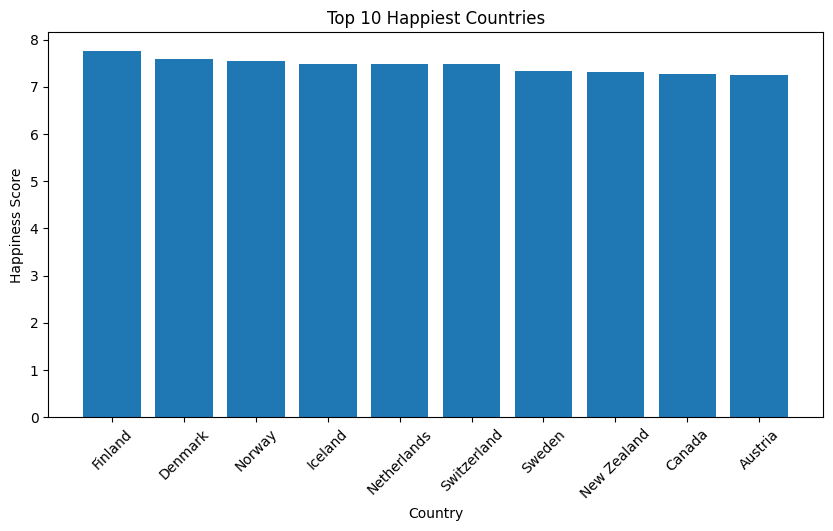

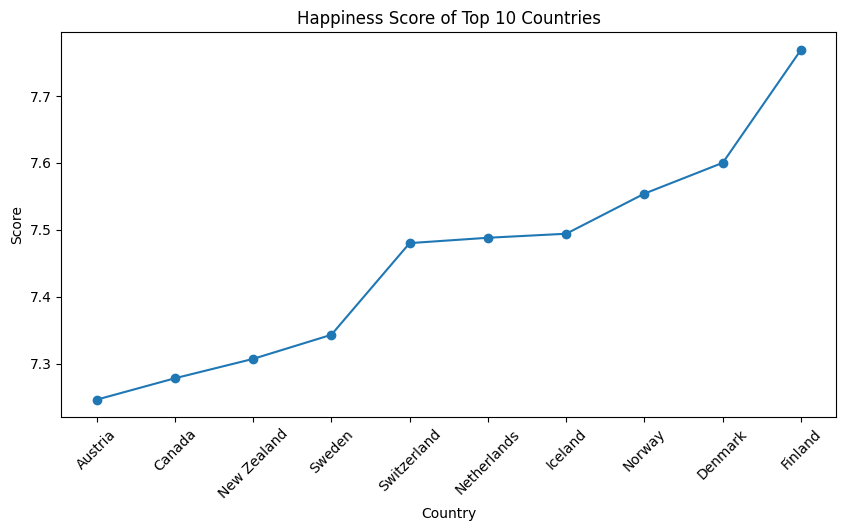

In [35]:
top10 = df.nlargest(10,'Score')

plt.figure(figsize=(10,5))
plt.bar(top10['Country or region'], top10['Score'])

plt.title('Top 10 Happiest Countries')
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45)

top10 = top10.sort_values('Score')

plt.figure(figsize=(10,5))
plt.plot(top10['Country or region'],
         top10['Score'],
         marker='o')

plt.title('Happiness Score of Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Score')
plt.xticks(rotation=45)



plt.show()

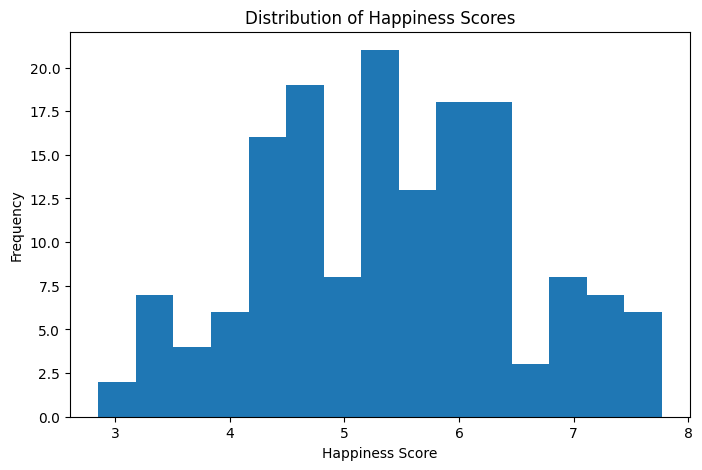

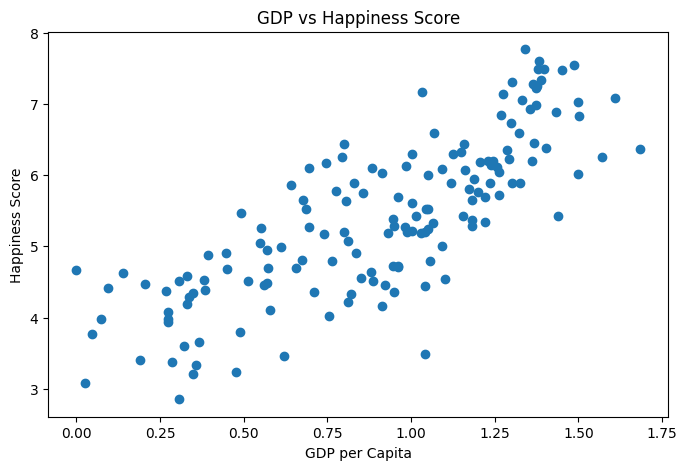

In [36]:
plt.figure(figsize=(8,5))

plt.hist(df['Score'],
         bins=15)

plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.figure(figsize=(8,5))

plt.scatter(df['GDP per capita'],
            df['Score'])

plt.title('GDP vs Happiness Score')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

plt.show()


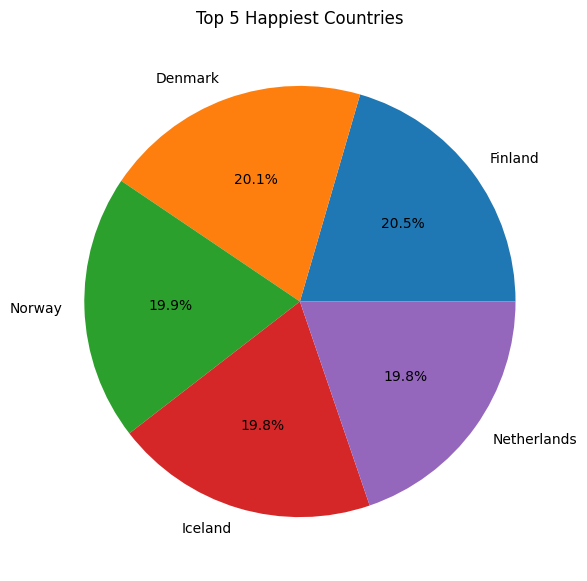

In [37]:
top5 = df.nlargest(5,'Score')

plt.figure(figsize=(7,7))

plt.pie(top5['Score'],
        labels=top5['Country or region'],
        autopct='%1.1f%%')

plt.title('Top 5 Happiest Countries')

plt.show()

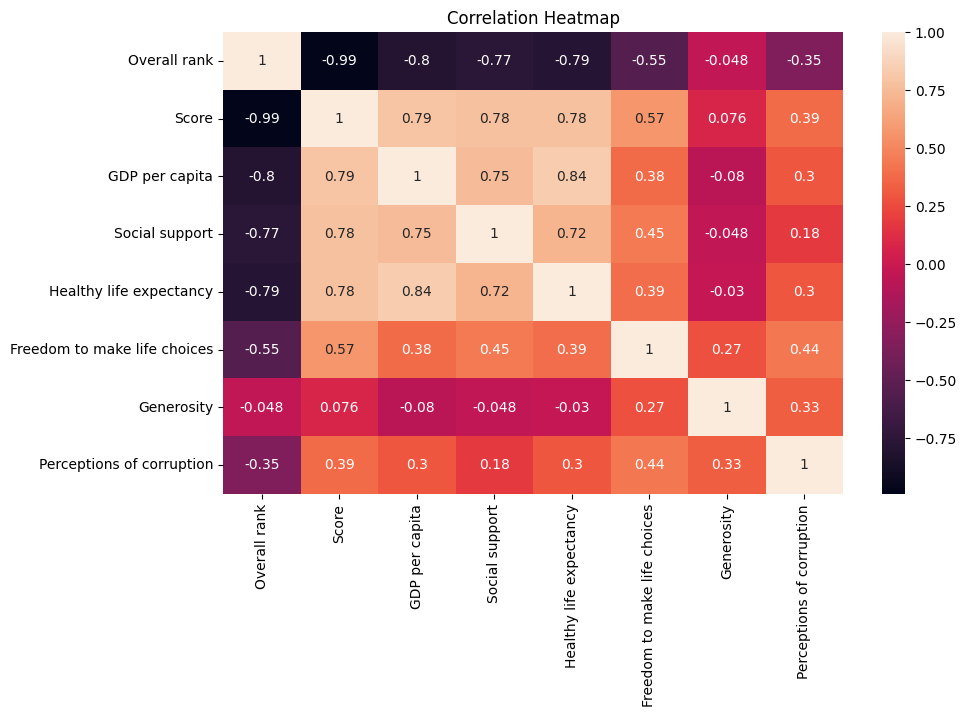

In [38]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

INSIGHT REPORT

1. The bar chart shows that the top-ranked countries consistently achieve happiness scores above the global average.

2. The scatter plot indicates a strong positive relationship between GDP per capita and happiness score, suggesting economic prosperity contributes to well-being.

3. The heatmap reveals that social support and healthy life expectancy have strong positive correlations with happiness score.

4. The histogram shows that most countries fall within the middle range of happiness scores, with relatively few countries at the extreme ends.

5. The pie chart demonstrates that the happiest countries contribute a significant share of the total happiness among the top-performing nations.
